# How large can my memory be while still maintaining less control resources than a memory-less system

In [1]:
import numpy as np 
import matplotlib.pyplot as plt


# RAM Surface Code Scaling with coherence time 
Consider gate time, and mode coherence

error correction cycle length \(t_{log}\). main error
error on physical qubit $$p = \frac{t_{log}}{T_{\text{coh},qub}}$$
error on memory $$p_{mem,idle} =  \frac{(N-1) *( t_{log} + 2t_{swap})}{T_{\text{coh},mem}}  $$
error on memory swap $$p_{mem, gate} = t_{swap}*(\frac{1}{T_{\text{coh}, mem}} + \frac{1}{T_{\text{coh}, qub}})$$
$$$$

Plots 
x axis: t1 qub
y axis : t1 mem 
z axis: lower bound on number of raqm/ upper 
two of these plots 

at error rate 1e-10

## Remember fundamental equations 
### memory less system 
$$\varepsilon = \left(\frac{p  }{p_{\text{threshold1}}}\right)^{D}$$
### memory full system 
$$\varepsilon' = \left(\frac{p  }{p_{\text{threshold1}}}+\frac{p_{mem}}{p_{\text{threshold2}}}\right)^{D'}$$

### Comparison of resources 
c = 3 (z + x + ancilla control)
$$(c+1)D'^2 <cND^2$$

In [3]:
def p_qubit(t_log_cycle, T_coh_qubit):
    '''
    $$p = \frac{t_{log}}{T_{\text{coh},qub}}$$
    '''
    return t_log_cycle / T_coh_qubit

def p_swap(t_swap, T_coh_cav, T_coh_qubit):
    '''
    2 total swaps, half in qubit, half in cavity
    $$p_{swap} = \frac{t_{swap}}{T_{\text{coh},cav}} + \frac{t_{swap}}{T_{\text{coh},qub}}$$
    '''
    return t_swap / T_coh_cav + t_swap / T_coh_qubit

def p_mem_idle(t_log_cycle, t_swap, N, T_coh_cav):
    '''
    Time spent idle in memory is (N-1) * (t_log_cycle + 2*t_swap) / T_coh_cav
    # '''
    # print(f"Memory idle time: {(N-1) * (t_log_cycle + 2*t_swap)}")
    return (N-1) * (t_log_cycle + 2*t_swap) / T_coh_cav

def find_d_prime(vareps, t_log_cycle, t_swap, N, T_coh_cav, T_coh_qubit, p_threshold1=0.01, p_threshold2=0.01):
    # $$\varepsilon' = \left(\frac{p + p_{mem}}{p_{\text{threshold}}}\right)^{D'}$$
    
    # print(f"p_qubit: {p_qubit(t_log_cycle, T_coh_qubit)}")
    # print(f"p_mem_idle: {p_mem_idle(t_log_cycle, t_swap, N, T_coh_cav)}")
    # print(f"p_swap: {p_swap(t_swap, T_coh_cav, T_coh_qubit)}")
    p = p_qubit(t_log_cycle, T_coh_qubit)/p_threshold1 + p_mem_idle(t_log_cycle, t_swap, N, T_coh_cav)/p_threshold2 + p_swap(t_swap, T_coh_cav, T_coh_qubit)/p_threshold2
    base = p

    if np.round(base,3)>=1: 
        return -1

    return np.log(vareps) / np.log(base)

def find_d(vareps, t_log_cycle, T_coh_qubit, p_threshold1=0.01, p_threshold2=0.01):
    
    # \varepsilon = \left(\frac{p}{p_{\text{threshold}}}\right)^{D}
    
    p = p_qubit(t_log_cycle, T_coh_qubit)
    base = p/p_threshold1
    # print(f"p: {p}, base: {base}")

    if np.round(base,3)>=1: 
        return -1

    return np.log(vareps) / np.log(base)


# find the lowest N and highest N for which $$2D'^2 <ND^2$$
def find_N_bounds(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit, p_threshold1=0.01, p_threshold2=0.01, N_min=1, N_max=1000, c= 3):
    '''
    Find the lowest and highest N for which 2D'^2 < N D^2
    Returns (N_low, N_high) or (None, None) if no such N exists.
    '''
    D = find_d(vareps, t_log_cycle, T_coh_qubit, p_threshold1, p_threshold2)
    N_low, N_high = None, None
    for N in range(N_min, N_max+1):
        Dp = find_d_prime(vareps, t_log_cycle, t_swap, N, T_coh_cav, T_coh_qubit, p_threshold1, p_threshold2)
        # print(f"N={N}, D'={Dp}, D={D}, 2D'^2={2*Dp**2}, ND^2={N*(D**2)}")
        if Dp < 0 or D < 0:
            continue
        if (c+1)*Dp**2 < c*N*D**2:
            if N_low is None:
                N_low = N
            N_high = N
    return N_low, N_high

# find the N for which control lines efficiency is maximized
def find_efficiency(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit, p_threshold1=0.01, p_threshold2=0.01, N_min=1, N_max=50000, c= 3):
    '''
    Find the optimal N for control lines are most efficienct
    '''
    D = find_d(vareps, t_log_cycle, T_coh_qubit, p_threshold1, p_threshold2)
    best_efficiency, N_best = None, None
    for N in range(N_min, N_max+1, 10):
        Dp = find_d_prime(vareps, t_log_cycle, t_swap, N, T_coh_cav, T_coh_qubit, p_threshold1, p_threshold2)
        # print(f"N={N}, D'={Dp}, D={D}, 2D'^2={2*Dp**2}, ND^2={N*(D**2)}")
        if Dp < 0 or D < 0:
            continue
        
        efficiency = (c*N*D**2) / ((c+1)*Dp**2)
        if best_efficiency is None or (efficiency > best_efficiency and efficiency > 1):
            best_efficiency = efficiency
            N_best = N
        # if (c+1)*Dp**2 < c*N*D**2:
        #     if N_low is None:
        #         N_low = N
        #     N_high = N
    if best_efficiency is not None and best_efficiency < 1:
        best_efficiency = None
        N_best = None
    return best_efficiency, N_best

# Example usage:
vareps = 1e-10 # doesnt matter!
t_log_cycle = 1e-6 #https://arxiv.org/pdf/2408.13687v1 have 42 ns cz (check readout)
t_swap = 1e-7 #https://arxiv.org/abs/2303.00959 have 100 ns swaps
T_coh_cav = 30e-3
T_coh_qubit = 1e-3

# debug d' 
# Dp = find_d_prime(vareps, t_log_cycle, t_swap, 10, T_coh_cav, T_coh_qubit)
# print(f"D': {Dp}")

N_low, N_high = find_N_bounds(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit)
print(f"Lowest N: {N_low}, Highest N: {N_high}")
efficiency, N_best = find_efficiency(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit)
print(f"Best efficiency: {efficiency} at N={N_best}")




Lowest N: 2, Highest N: 178
Best efficiency: 9.924195500531209 at N=41


In [8]:
# now we vary t_coh_qubit (x axis) and t_coh_cav (y axis) and plot N_low and N_high
T_coh_qubit_vals = np.logspace(-5, -2, 50)
T_coh_cav_vals = np.logspace(-4, 0, 50)

N_low_vals = []
N_high_vals = []

for T_coh_qubit in T_coh_qubit_vals:
    for T_coh_cav in T_coh_cav_vals:
        N_low, N_high = find_N_bounds(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit)
        if N_low is None:
            N_low = np.nan
        if N_high is None:
            N_high = np.nan
        N_low_vals.append(N_low)
        N_high_vals.append(N_high)



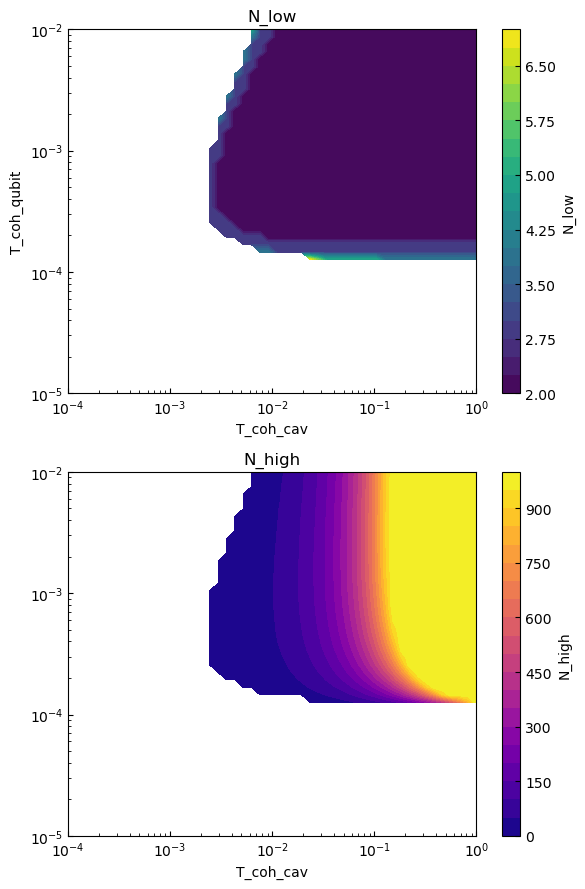

In [9]:
# Reshape results for plotting
N_low_vals = np.array(N_low_vals).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))
N_high_vals = np.array(N_high_vals).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))

# Make a mask where data are outside your contour limits
# mask_low = (N_low_vals < 1) | (N_low_vals > 20)
# Plot contours of N_low and N_high
fig, axs = plt.subplots(2, 1, figsize=(6, 9), sharey=True)


# N_low contour
c0 = axs[0].contourf(T_coh_cav_vals, T_coh_qubit_vals, N_low_vals, levels=20, cmap='viridis')
axs[0].set_title('N_low')
axs[0].set_xlabel('T_coh_cav')
axs[0].set_ylabel('T_coh_qubit')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
# axs[0].imshow(mask_low, extent=[T_coh_cav_vals.min(), T_coh_cav_vals.max(),
#                                 T_coh_qubit_vals.min(), T_coh_qubit_vals.max()],
#               origin='lower', aspect='auto', cmap='Greys', alpha=0.9)

fig.colorbar(c0, ax=axs[0], label='N_low')
# recale colorbar to be max of 5
# c0.set_clim(1, 20)

# N_high contour
c1 = axs[1].contourf(T_coh_cav_vals, T_coh_qubit_vals, N_high_vals, levels=20, cmap='plasma')
axs[1].set_title('N_high')
axs[1].set_xlabel('T_coh_cav')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
# axs[1].imshow(mask_low, extent=[T_coh_cav_vals.min(), T_coh_cav_vals.max(),
#                                 T_coh_qubit_vals.min(), T_coh_qubit_vals.max()],
#               origin='lower', aspect='auto', cmap='Greys', alpha=0.9)
fig.colorbar(c1, ax=axs[1], label='N_high')

plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.tight_layout()
# plt.savefig('memory_size_contours.pdf', dpi=300)
plt.show()




# Find the best control lines efficiency and corresponding memory size

In [10]:
# now we vary t_coh_qubit (x axis) and t_coh_cav (y axis) and plot N_low and N_high
T_coh_qubit_vals = np.logspace(-5, -2, 50)
T_coh_cav_vals = np.logspace(-4, 0, 50)

N_best_vals = []
efficiency_best_vals = []

for T_coh_qubit in T_coh_qubit_vals:
    for T_coh_cav in T_coh_cav_vals:
        efficiency, N_best = find_efficiency(vareps, t_log_cycle, t_swap, T_coh_cav, T_coh_qubit)
        if efficiency is None:
            efficiency = np.nan
        if N_best is None:
            N_best = np.nan
        N_best_vals.append(N_best)
        efficiency_best_vals.append(efficiency)



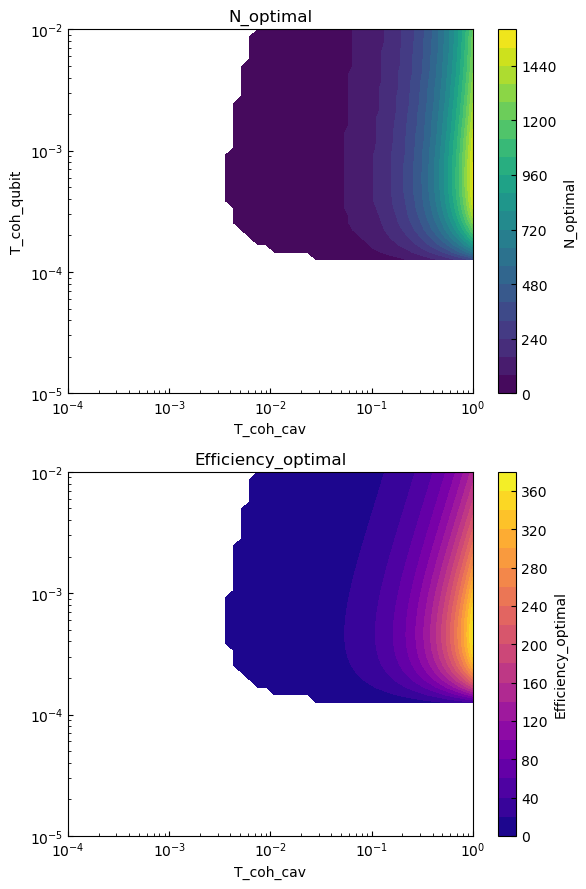

In [11]:
# Reshape results for plotting
N_best_vals = np.array(N_best_vals).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))
efficiency_best_vals = np.array(efficiency_best_vals).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))

# Make a mask where data are outside your contour limits
# mask_low = (N_low_vals < 1) | (N_low_vals > 20)
# Plot contours of N_low and N_high
fig, axs = plt.subplots(2, 1, figsize=(6, 9), sharey=True)


# N_low contour
c0 = axs[0].contourf(T_coh_cav_vals, T_coh_qubit_vals, N_best_vals, levels=20, cmap='viridis')
axs[0].set_title('N_optimal')
axs[0].set_xlabel('T_coh_cav')
axs[0].set_ylabel('T_coh_qubit')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
# axs[0].imshow(mask_low, extent=[T_coh_cav_vals.min(), T_coh_cav_vals.max(),
#                                 T_coh_qubit_vals.min(), T_coh_qubit_vals.max()],
#               origin='lower', aspect='auto', cmap='Greys', alpha=0.9)

fig.colorbar(c0, ax=axs[0], label='N_optimal')
# recale colorbar to be max of 5
# c0.set_clim(1, 20)

# N_high contour
c1 = axs[1].contourf(T_coh_cav_vals, T_coh_qubit_vals, efficiency_best_vals, levels=20, cmap='plasma')

axs[1].set_title('Efficiency_optimal')
axs[1].set_xlabel('T_coh_cav')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
# axs[1].imshow(mask_low, extent=[T_coh_cav_vals.min(), T_coh_cav_vals.max(),
#                                 T_coh_qubit_vals.min(), T_coh_qubit_vals.max()],
#               origin='lower', aspect='auto', cmap='Greys', alpha=0.9)
fig.colorbar(c1, ax=axs[1], label='Efficiency_optimal')
# c1.set_clim(1, 15)

plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.tight_layout()
plt.savefig('memory_size_contours_new_0329.pdf', dpi=300)
plt.show()




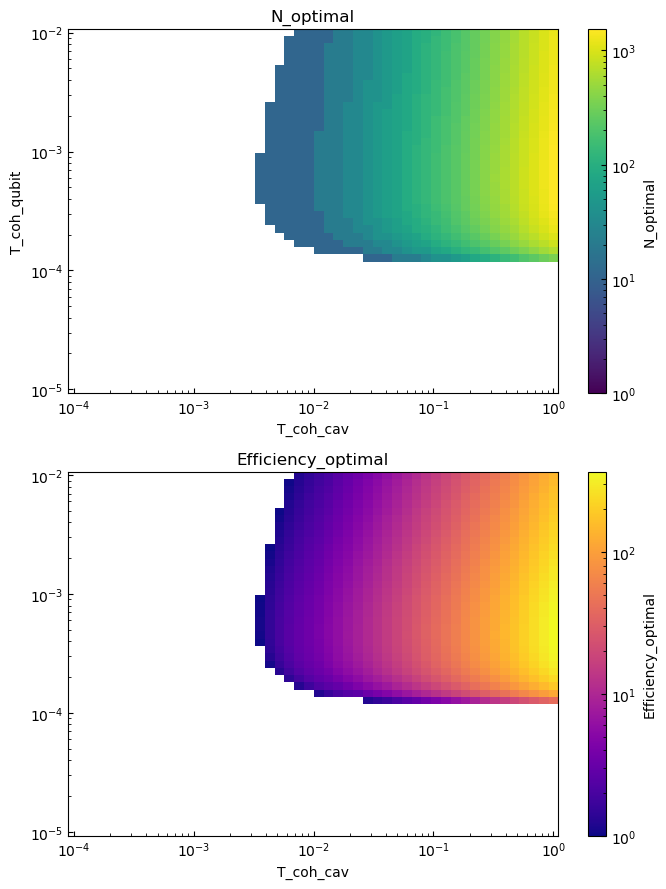

In [12]:
from matplotlib.colors import LogNorm

# --- data prep ---
N_best_vals = np.array(N_best_vals, dtype=float).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))
efficiency_best_vals = np.array(efficiency_best_vals, dtype=float).reshape(len(T_coh_qubit_vals), len(T_coh_cav_vals))

# force strictly positive for log
N_best_vals = np.clip(N_best_vals, 1e-12, None)
efficiency_best_vals = np.clip(efficiency_best_vals, 1e-12, None)

# force vmin = 1; vmax from data
vmin0, vmax0 = 1, float(np.nanmax(N_best_vals))
vmin1, vmax1 = 1, float(np.nanmax(efficiency_best_vals))

X, Y = np.meshgrid(T_coh_cav_vals, T_coh_qubit_vals)  # match your axes

fig, axs = plt.subplots(2, 1, figsize=(7, 9), sharey=True)

# --- N_optimal heatmap (exact [1, vmax0]) ---
m0 = axs[0].pcolormesh(
    X, Y, N_best_vals, shading='auto',
    norm=LogNorm(vmin=vmin0, vmax=vmax0), cmap='viridis'
)
axs[0].set_title('N_optimal')
axs[0].set_xlabel('T_coh_cav'); axs[0].set_ylabel('T_coh_qubit')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
cb0 = fig.colorbar(m0, ax=axs[0], label='N_optimal')

# optional: add contour lines (purely for edges/labels)
# axs[0].contour(X, Y, N_best_vals, levels=10, colors='k', linewidths=0.4)

# --- Efficiency_optimal heatmap (exact [1, vmax1]) ---
m1 = axs[1].pcolormesh(
    X, Y, efficiency_best_vals, shading='auto',
    norm=LogNorm(vmin=vmin1, vmax=vmax1), cmap='plasma'
)
axs[1].set_title('Efficiency_optimal')
axs[1].set_xlabel('T_coh_cav')
axs[1].set_xscale('log'); axs[1].set_yscale('log')
cb1 = fig.colorbar(m1, ax=axs[1], label='Efficiency_optimal')

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.tight_layout()
plt.savefig('memory_size_contours_new_0329.pdf', dpi=300)
plt.show()

In [22]:
print("N_best unique:", np.unique(N_best_vals))
print("Efficiency unique (rounded):", np.unique(np.round(efficiency_best_vals, 6))[:20],
      "… count =", np.unique(np.round(efficiency_best_vals, 6)).size)

N_best unique: [1.1000e+01 2.1000e+01 3.1000e+01 4.1000e+01 5.1000e+01 6.1000e+01
 7.1000e+01 8.1000e+01 9.1000e+01 1.0100e+02 1.1100e+02 1.2100e+02
 1.3100e+02 1.4100e+02 1.5100e+02 1.6100e+02 1.7100e+02 1.8100e+02
 1.9100e+02 2.0100e+02 2.1100e+02 2.2100e+02 2.3100e+02 2.4100e+02
 2.5100e+02 2.6100e+02 2.7100e+02 2.8100e+02 2.9100e+02 3.0100e+02
 3.1100e+02 3.2100e+02 3.3100e+02 3.4100e+02 3.5100e+02 3.6100e+02
 3.7100e+02 3.8100e+02 3.9100e+02 4.0100e+02 4.1100e+02 4.2100e+02
 4.3100e+02 4.4100e+02 4.5100e+02 4.6100e+02 4.7100e+02 4.8100e+02
 4.9100e+02 5.0100e+02 5.1100e+02 5.2100e+02 5.3100e+02 5.4100e+02
 5.5100e+02 5.6100e+02 5.7100e+02 5.8100e+02 5.9100e+02 6.0100e+02
 6.1100e+02 6.2100e+02 6.3100e+02 6.4100e+02 6.5100e+02 6.6100e+02
 6.7100e+02 6.8100e+02 6.9100e+02 7.0100e+02 7.1100e+02 7.2100e+02
 7.3100e+02 7.4100e+02 7.5100e+02 7.6100e+02 7.7100e+02 7.8100e+02
 7.9100e+02 8.0100e+02 8.1100e+02 8.2100e+02 8.3100e+02 8.4100e+02
 8.5100e+02 8.6100e+02 8.7100e+02 8.8100e+02 8.

## RAM surface code scaling
$$\varepsilon' = \left(\frac{p + 2Np_{\text{swap}}/8}{p_{\text{threshold}}}\right)^{D'}$$

Control Resources per logical qubit $r = 2D'^2 /N$



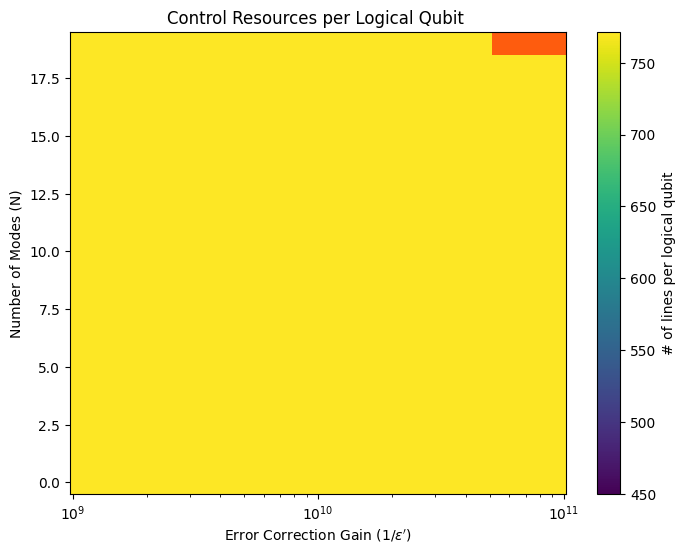

In [52]:
def D_prime(vareps_prime, N, p_swap = 0.001, p_threshold = 0.01, p = 0.005):    
    # Solve for D' in terms of vareps_prime and N
    # vareps_prime = ((p + 2*N*p_swap/8) / p_threshold) ** D'
    # Take log on both sides:
    # log(vareps_prime) = D' * log((p + 2*N*p_swap/8) / p_threshold)
    # D' = log(vareps_prime) / log((p + 2*N*p_swap/8) / p_threshold)
    # p = 0.01
    # p_swap = 0.005
    # p_threshold = 0.1
    base = (p + 2 * N * p_swap / 8) / p_threshold

    if base>1: 
        return 100000

    return np.log(vareps_prime) / np.log(base)



def plot_control_resources(vareps_prime_vals, N_vals, D_prime_func):
    import matplotlib.colors as mcolors

    # Compute Z as before
    X, Y = np.meshgrid(1/np.array(vareps_prime_vals), N_vals)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Dp = D_prime_func(1/X[i, j], Y[i, j])
            if Y[i, j] == 0:
                Z[i, j] = 2 * Dp**2
            else:
                Z[i, j] = 2 * Dp**2 / Y[i, j]

    # Create a masked array for values > 500
    Z_masked = np.ma.masked_where(Z <= 100000, Z)

    plt.figure(figsize=(8, 6))
    c = plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', norm=mcolors.Normalize(vmin=Z.min(), vmax=500))
    plt.pcolormesh(X, Y, Z_masked, shading='auto', cmap=mcolors.ListedColormap(['red']), alpha=0.6)
    plt.xscale('log')
    plt.xlabel("Error Correction Gain ($1/\\varepsilon'$)")
    plt.ylabel("Number of Modes (N)")
    plt.title("Control Resources per Logical Qubit ")
    plt.colorbar(c, label="# of lines per logical qubit")
    plt.show()

N_vals = np.arange(0, 20,1)
vareps_prime_vals = np.logspace(-11, -9, 100)
plot_control_resources(vareps_prime_vals, N_vals, D_prime)
# plt.xscale('log')

In [53]:
 

def D_prime(vareps_prime, N, p_swap = 0.001, p_threshold = 0.01, p = 0.005):    
    # Solve for D' in terms of vareps_prime and N
    # vareps_prime = ((p + 2*N*p_swap/8) / p_threshold) ** D'
    # Take log on both sides:
    # log(vareps_prime) = D' * log((p + 2*N*p_swap/8) / p_threshold)
    # D' = log(vareps_prime) / log((p + 2*N*p_swap/8) / p_threshold)
    # p = 0.01
    # p_swap = 0.005
    # p_threshold = 0.1
    base = (p + 2 * N * p_swap / 8) / p_threshold

    if base>1: 
        return 500

    return np.log(vareps_prime) / np.log(base)



def plot_control_resources(vareps_prime_vals, N_vals, D_prime_func):
    import matplotlib.colors as mcolors

    # Compute Z as before
    X, Y = np.meshgrid(1/np.array(vareps_prime_vals), N_vals)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Dp = D_prime_func(1/X[i, j], Y[i, j])
            if Y[i, j] == 0:
                Z[i, j] = 2 * Dp**2
            else:
                Z[i, j] = 2 * Dp**2 / Y[i, j]

    # Create a masked array for values > 500
    Z_masked = np.ma.masked_where(Z <= 500, Z)

    plt.figure(figsize=(8, 6))
    c = plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', norm=mcolors.Normalize(vmin=Z.min(), vmax=500))
    plt.pcolormesh(X, Y, Z_masked, shading='auto', cmap=mcolors.ListedColormap(['red']), alpha=0.6)
    plt.xscale('log')
    plt.xlabel("Error Correction Gain ($1/\\varepsilon'$)")
    plt.ylabel("Number of Modes (N)")
    plt.title("Control Resources per Logical Qubit ")
    plt.colorbar(c, label="# of lines per logical qubit")
    plt.show()


# I  want a table of color plots  with x axis being p swap and y axis being p 
# us the functions below
# Define ranges for p_swap and p
p_swap_vals = np.linspace(0.0001, 0.01, 4)
p_vals = np.linspace(0.001, 0.02, 4)

fig, axes = plt.subplots(len(p_vals), len(p_swap_vals), figsize=(16, 12), sharex=True, sharey=True)

for i, p in enumerate(p_vals):
    for j, p_swap in enumerate(p_swap_vals):
        def D_prime_custom(vareps_prime, N):
            base = (p + 2 * N * p_swap / 8) / 0.01  # p_threshold fixed at 0.01
            if base > 1:
                return 500
            return np.log(vareps_prime) / np.log(base)
        
        X, Y = np.meshgrid(1/np.array(vareps_prime_vals), N_vals)
        Z = np.zeros_like(X)
        for m in range(X.shape[0]):
            for n in range(X.shape[1]):
                Dp = D_prime_custom(1/X[m, n], Y[m, n])
                if Y[m, n] == 0:
                    Z[m, n] = 2 * Dp**2
                else:
                    Z[m, n] = 2 * Dp**2 / Y[m, n]
        Z_masked = np.ma.masked_where(Z <= 500, Z)
        ax = axes[i, j]
        c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', vmin=Z.min(), vmax=500)
        ax.pcolormesh(X, Y, Z_masked, shading='auto', cmap=plt.cm.Reds, alpha=0.6)
        ax.set_xscale('log')
        if i == len(p_vals) - 1:
            ax.set_xlabel("$1/\\varepsilon'$")
        if j == 0:
            ax.set_ylabel("N")
        ax.set_title(f"p={p:.3g}, p_swap={p_swap:.4f}")

fig.suptitle("Control Resources per Logical Qubit for varying p and p_swap", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.colorbar(c, ax=axes, orientation='vertical', label="# of lines per logical qubit")
plt.show()

# N_vals = np.arange(0, 10,1)
# vareps_prime_vals = np.logspace(-5, -1, 100)
# plot_control_resources(vareps_prime_vals, N_vals, D_prime)
# plt.xscale('log')

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1600x1200 with 17 Axes>

import numpy as n